# Mudcard
- **is xgboost considerably more expensive than random forest? when is it better to run random forest over xgboost?**
    - random forests are trivial to run parallel on multiple computer cores becaues the trees are independent
    - the developers of XGBoost developed a really clever algorithm to train models on GPUs and to parallelize computations on multiple cores
    - becaues of this, XGBoost is not considerably more expensive to develop
    - the general advise is to try both models (in fact as many as you can) on your dataset because we cannot know in advance which model might be best
    - often XGBoost performs better than RF but sometimes RF is better than XGB
- **How do we define the 'loss' between tree layers? How do we know one layer is working well?**
    - there are no layers in trees, only in neural networks
    - you might be referring to tree depth instead of layers or a node?
    - the loss function used for decision trees is called gain, you can read about it [here](https://en.wikipedia.org/wiki/Information_gain_(decision_tree))
- **How we gonna know if there is exit monotonic relationship? based on the priority knowledge?**
    - not priority but prior knowledge :)
    - Yes, that's uually the way to go.
    - The example Asher talked about is predicting whether a food item is dessert or not.
    - if one of the features is how much sugar is in one portion of that food item, it is reasonable to assume that the more sugar a food item contains, the more likely that the food item is a dessert
    - So we want the correlation between sugar content and the probability that a food item is dessert to be monotonic increasing
    - this is what we mean by prior knowledge on a problem
- **Hoping to learn more about implementation barriers, didn't quite understand the monotonic relationship and how that relates to missing values**
    - thiose are to different and independent concepts
    - trees deal well with missing values
    - and you can also enforce monotonic relationships between features and the target variable

# Non-linear ML algorithms - Support Vector Machines
By the end of this lecture, you will be able to
- Describe how linear SVMs work and what support vectors are
- Apply non-linear SVMs with radial basis functions (gaussian kernel)
- Discuss what secondary considerations might go into selecting/excluding ML models

# <font color='LIGHTGRAY'>Non-linear ML algorithms - Support vector machines</font>
<font color='LIGHTGRAY'>By the end of this lecture, you will be able to</font>
- **Describe how linear SVMs work and what support vectors are**
- <font color='LIGHTGRAY'>Apply non-linear SVMs with radial basis functions (gaussian kernel)</font>
- <font color='LIGHTGRAY'>Discuss what secondary considerations might go into selecting/excluding ML models</font>

## Linear Support Vector Machines
- let's consider a simple binary classification problem with two features
- the two classes are linearly separable meaning that you can find a linear decision boundary which gives 0 error on the training set
- here is an example:

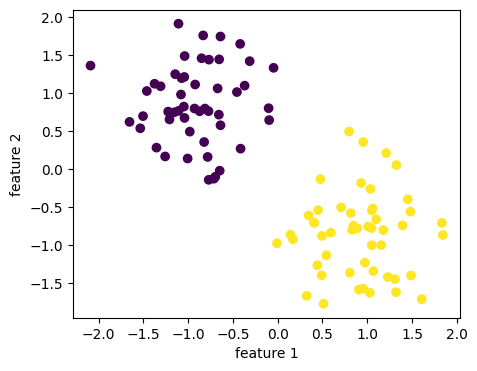

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler


X_train, y_train = make_blobs(n_samples=100, n_features = 2, centers = 2, cluster_std = 2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

plt.figure(figsize=(5,4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

Based on the logistic regression lecture, we can draw linear decision boudnaries for this dataset.

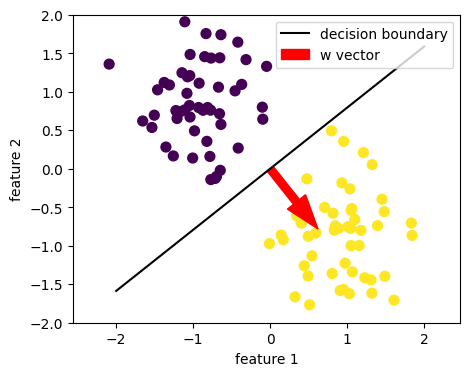

In [ ]:
# create the w vector:
w = np.zeros([2])

phi = -0.9 # [radians] any value between -0.1 and -0.9 gives 0 loss on the training data!
length = 1

w[0] = np.cos(phi)*length
w[1] = np.sin(phi)*length

# calculate the decision boundary - it's a line perpendicular to the w vector
# x_2 = -\frac{w_1}{w_2} x_1 for halfspace, linear seperate
a = -w[0] / w[1]
xx = np.linspace(-2, 2)
yy = a * xx

plt.figure(figsize=(5,4))
plt.axis('equal')
plt.ylim((-2,2))
# visualize the decision boundary
plt.plot(xx, yy, "k-",label='decision boundary')

# add the datapoints
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,s=50)
plt.xlabel('feature 1')
plt.ylabel('feature 2')

# add the w vector
plt.arrow(0,0,w[0],w[1],width=0.1,length_includes_head=True,color='r',label='w vector')
plt.legend()
plt.show()

- any phi between -0.1 and -0.9 radians give a 0 loss on the training data!
- which one should we choose?
- not all decision boundaries are created equal!
- margin helps us answer this question

## Margin
- the minimum distance between any training point and the decision boundary
- light blue region on the figures

<center><img src = '../figures/margin_example1.png' width="350"><img src = '../figures/margin_example2.png' width="350"></center>

- out of the inifnite number of decision boundaries we could choose, we want one that maximizes the margin (example 2 in this case)!
- this is the key idea of a support vector machine


## What are the support vectors?
- **The support vectors are data points that define the margin**
- each data point is a vector in the feature space
- the points that 'support' or define the margin are the support vectors
- the other points don't matter because the decision boundary and the margin are only impacted by the support vectors!
- let's visualize the linear SVM and the support vectors on the toy dataset:

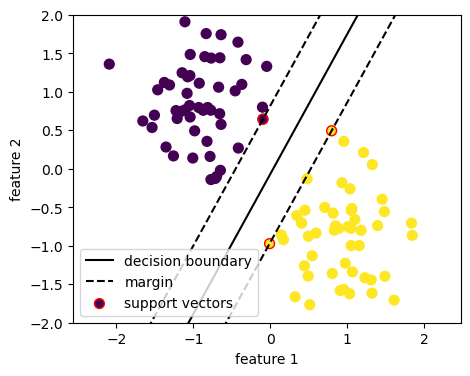

In [3]:
from sklearn.svm import SVC

clf = SVC(kernel='linear',probability=True,C=1e10) # linear SVM with no or very little regularization (C = 1 / regularization strength)
clf.fit(X_train,y_train)

plt.figure(figsize=(5,4))
plt.axis('equal')

# get the separating hyperplane
w = clf.coef_[0] # this is the w vector
a = -w[0] / w[1]
xx = np.linspace(-2, 2)
yy = a * xx - (clf.intercept_[0]) / w[1]

# plot the parallels to the separating hyperplane that pass through the
# support vectors (margin away from hyperplane in direction
# perpendicular to hyperplane). This is sqrt(1+a^2) away vertically in
# 2-d.
margin = 1 / np.sqrt(np.sum(clf.coef_**2))
yy_down = yy - np.sqrt(1 + a**2) * margin
yy_up = yy + np.sqrt(1 + a**2) * margin

plt.ylim((-2,2))
plt.plot(xx, yy, "k-",label='decision boundary')
plt.plot(xx, yy_down, "k--",label='margin')
plt.plot(xx, yy_up, "k--")

# add the datapoints
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,s=50)
# clf.support_ is the indices of the support vectors!
plt.scatter(X_train[clf.support_,0],X_train[clf.support_,1],c=y_train[clf.support_],s=50,edgecolors='r',label= 'support vectors')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend(loc=3)
plt.show()



## Quiz 1

How many support vectors are there in the example below?

<center><img src = '../figures/margin_example3.png' width="450"></center>


# <font color='LIGHTGRAY'>Non-linear ML algorithms - Support vector machines</font>
<font color='LIGHTGRAY'>By the end of this lecture, you will be able to</font>
- <font color='LIGHTGRAY'>Describe how linear SVMs work and what support vectors are</font>
- **Apply non-linear SVMs with radial basis functions (gaussian kernel)**
- <font color='LIGHTGRAY'>Discuss what secondary considerations might go into selecting/excluding ML models</font>

# Non-linear SVMs
- non-linear SVMs are an extension of linear SVMs
- The idea is to map or embed the data points into a higher (sometimes infinite) dimensional feature space where the problem is linearly separable
    - think polynomial regression in lecture 8!
- We train a linear SVM in this higher dimensional space
- It can be very computationally expensive to perform feature transformations and to train a linear SVM in a very high dimensional space.
    - if the feature space is infinite dimensional, this is in fact impossible to do computationally
- A mathematical trick called the **kernel trick** is applied to perform these operations in a computationally efficient manner
- the math is pretty complex and beyond this course
- recommend CSCI1420 or DATA2060 to dive deeper into ML algorithms
- If you don't plan to take those courses but want to learn more, check out [this post](https://medium.com/data-science/the-kernel-trick-c98cdbcaeb3f) for a high level overview

## Gaussian SVMs
- SVM with a Gaussian or radial basis function kernel
- popular choice among possible non-linear SVM kernels
- this kernel basically smoothes datapoints to multi-dimensional gaussians

### SVM in regression

In [1]:
import numpy as np
from sklearn.svm import SVR
np.random.seed(10)
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

n_samples = 30

X = np.random.rand(n_samples)
y = true_fun(X) + np.random.randn(n_samples) * 0.1

X_new = np.linspace(-0.5, 1.5, 2000)

reg = SVR(gamma = 1, C = 1)
reg.fit(X[:, np.newaxis],y)
y_new = reg.predict(X_new[:, np.newaxis])


In [5]:
help(SVR)

Help on class SVR in module sklearn.svm._classes:

class SVR(sklearn.base.RegressorMixin, sklearn.svm._base.BaseLibSVM)
 |  SVR(*, kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False, max_iter=-1)
 |
 |  Epsilon-Support Vector Regression.
 |
 |  The free parameters in the model are C and epsilon.
 |
 |  The implementation is based on libsvm. The fit time complexity
 |  is more than quadratic with the number of samples which makes it hard
 |  to scale to datasets with more than a couple of 10000 samples. For large
 |  datasets consider using :class:`~sklearn.svm.LinearSVR` or
 |  :class:`~sklearn.linear_model.SGDRegressor` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  Read more in the :ref:`User Guide <svm_regression>`.
 |
 |  Parameters
 |  ----------
 |  kernel : {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or ca

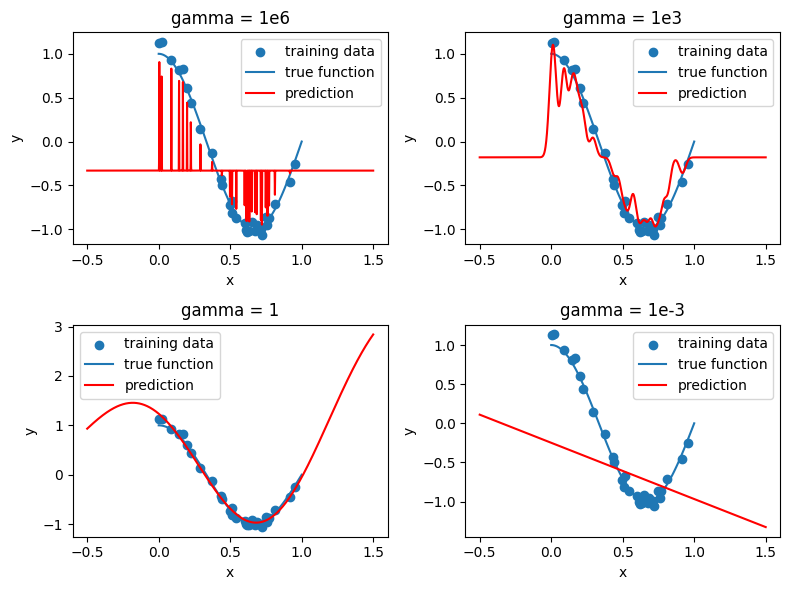

In [2]:
import matplotlib.pyplot as plt
import matplotlib


plt.figure(figsize=(8,6))

plt.subplot(2,2,1)
plt.scatter(X,y,label='training data')
plt.plot(np.linspace(0, 1, 100),true_fun(np.linspace(0, 1, 100)),label='true function')
reg = SVR(gamma = 1000000, C = 100)
reg.fit(X[:, np.newaxis],y)
y_new = reg.predict(X_new[:, np.newaxis])
plt.plot(X_new,y_new,'r',label='prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('gamma = 1e6')
plt.legend()

plt.subplot(2,2,2)
plt.scatter(X,y,label='training data')
plt.plot(np.linspace(0, 1, 100),true_fun(np.linspace(0, 1, 100)),label='true function')
reg = SVR(gamma = 1000, C = 100)
reg.fit(X[:, np.newaxis],y)
y_new = reg.predict(X_new[:, np.newaxis])
plt.plot(X_new,y_new,'r',label='prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('gamma = 1e3')
plt.legend()

plt.subplot(2,2,3)
plt.scatter(X,y,label='training data')
plt.plot(np.linspace(0, 1, 100),true_fun(np.linspace(0, 1, 100)),label='true function')
reg = SVR(gamma = 1, C = 100)
reg.fit(X[:, np.newaxis],y)
y_new = reg.predict(X_new[:, np.newaxis])
plt.plot(X_new,y_new,'r',label='prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('gamma = 1')
plt.legend()


plt.subplot(2,2,4)
plt.scatter(X,y,label='training data')
plt.plot(np.linspace(0, 1, 100),true_fun(np.linspace(0, 1, 100)),label='true function')
reg = SVR(gamma = 0.001, C = 100)
reg.fit(X[:, np.newaxis],y)
y_new = reg.predict(X_new[:, np.newaxis])
plt.plot(X_new,y_new,'r',label='prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('gamma = 1e-3')
plt.legend()

plt.tight_layout()
plt.savefig('../figures/SVM_reg.png',dpi=300)
plt.show()


### SVM in classification

In [7]:
from sklearn.datasets import make_moons
import numpy as np
from sklearn.svm import SVC

# create the data
X,y = make_moons(noise=0.2, random_state=1,n_samples=200)
# set the hyperparameters
clf = SVC(gamma = 1, C = 1, probability=True) # the default kernel is rbf
# fit the model
clf.fit(X,y)
# predict new data
#y_new = clf.predict(X_new)
# predict probabilities
#y_new = clf.predict_proba(X_new)

SVC(C=1, gamma=1, probability=True)

In [8]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a one-vs-one scheme.
 |
 |  For details on the precise mathematical formulation of the provided
 |  kernel functions and how `gamma`, `

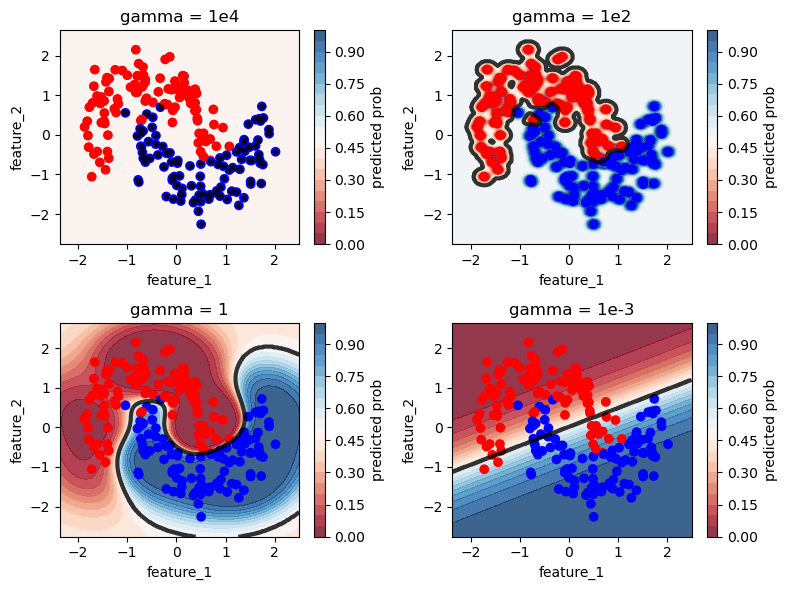

In [9]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)

h = .02  # step size in the mesh

x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

plt.figure(figsize=(8,6))
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
cm = plt.cm.RdBu

plt.subplot(2,2,1)
clf = SVC(gamma = 1e4, C = 100, probability=True)
clf.fit(X,y)
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8,vmin=0,vmax=1,levels=np.arange(0,1.05,0.05))
plt.colorbar(label='predicted prob')
plt.contour(xx, yy, Z, alpha=.8,vmin=0,vmax=1,levels=[0.5],colors=['k'],linewidths=3)
plt.scatter(X[:, 0], X[:, 1], c=y,cmap=cm_bright)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('gamma = 1e4')

plt.subplot(2,2,2)
clf = SVC(gamma = 1e2, C = 100, probability=True)
clf.fit(X,y)
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8,vmin=0,vmax=1,levels=np.arange(0,1.05,0.05))
plt.colorbar(label='predicted prob')
plt.contour(xx, yy, Z, alpha=.8,vmin=0,vmax=1,levels=[0.5],colors=['k'],linewidths=3)
plt.scatter(X[:, 0], X[:, 1], c=y,cmap=cm_bright)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('gamma = 1e2')

plt.subplot(2,2,3)
clf = SVC(gamma = 1e0, C = 100, probability=True)
clf.fit(X,y)
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8,vmin=0,vmax=1,levels=np.arange(0,1.05,0.05))
plt.colorbar(label='predicted prob')
plt.contour(xx, yy, Z, alpha=.8,vmin=0,vmax=1,levels=[0.5],colors=['k'],linewidths=3)
plt.scatter(X[:, 0], X[:, 1], c=y,cmap=cm_bright)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('gamma = 1')

plt.subplot(2,2,4)
clf = SVC(gamma = 1e-3, C = 100, probability=True)
clf.fit(X,y)
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8,vmin=0,vmax=1,levels=np.arange(0,1.05,0.05))
plt.colorbar(label='predicted prob')
plt.contour(xx, yy, Z, alpha=.8,vmin=0,vmax=1,levels=[0.5],colors=['k'],linewidths=3)
plt.scatter(X[:, 0], X[:, 1], c=y,cmap=cm_bright)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('gamma = 1e-3')


plt.tight_layout()

plt.savefig('../figures/SVM_clf.png',dpi=300)
plt.show()




figure 1 overfitted, fig 4 underfitted.

## Quiz 2

Bias variance trade off

Which gamma value gives the best trade off between high bias and high variance? Work through the steps to answer the question.

- Use random_state = 42 where-ever necessary.
- Split X, y into X_train, X_val, y_train, y_val such that 70% of the points are in train.
- Fit SVC models with C = 1, and gamma = 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3 on the training set.
- Measure the validation accuracy for each gamma.
- Which gamma value gives the highest validation accuracy?


In [14]:
# add your code here
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import make_moons
import numpy as np

X,y = make_moons(noise=0.2, random_state=42,n_samples=200)
X_train, X_other, y_train, y_other = train_test_split(X, y, train_size=0.7, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_other, y_other, train_size=0.5, random_state=42)
gammas = [1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3]
val_accuracy = []
for g in gammas:
    clf = SVC(gamma=g, C=1, random_state=42)
    clf.fit(X_train, y_train)
    val_accuracy.append(clf.score(X_val, y_val))
    
print(val_accuracy)
print('best gamma  =', gammas[np.argmax(val_accuracy)])



[0.4, 0.8666666666666667, 0.8666666666666667, 0.9666666666666667, 0.9333333333333333, 0.8666666666666667, 0.5333333333333333]
best gamma  = 1


•	Small gamma → too smooth → high bias → underfit

•	Large gamma → too wiggly → high variance → overfit

The best gamma is usually the middle values (often around 1e-1 or 1 for moons / blobs).


# <font color='LIGHTGRAY'>Non-linear ML algorithms - Support vector machines</font>
<font color='LIGHTGRAY'>By the end of this lecture, you will be able to</font>
- <font color='LIGHTGRAY'>Describe how linear SVMs work and what support vectors are</font>
- <font color='LIGHTGRAY'>Apply non-linear SVMs with radial basis functions (gaussian kernel)</font>
- **Discuss what secondary considerations might go into selecting/excluding ML models**

## Which ML algorithm to try on your dataset?

- other than predictive power, what else is important for you?
   - is it suitable for large datasets? 
   - how the model behaves with respect to outliers?
   - does the prediction varies smoothly with the feature values?
   - can the model capture non-linear dependencies?
   - is the model easy to interpret for a human?
- here is a table to summarize things

| ML algo | suitable for large datasets? | behaviour wrt outliers | non-linear? | params to tune | smooth predictions | easy to interpret? |
| - | :-: | :-: | :-: | :-: | :-: | :-: |
| linear regression            	|              yes             	|linear extrapolation|      no     	| l1 and/or l2 reg 	| yes | yes|
| logistic regression          	|              yes             	|scales with distance from the decision boundary|      no     	| l1 and/or l2 reg 	| yes | yes|
| random forest regression     	|so so |constant|yes|max_features,  max_depth| no|so so|
| random forest classification 	|so so |step-like, difficult to tell|yes|max_features,  max_depth| no|so so|
| SVM rbf regression               	|no|non-linear extrapolation|yes|C, gamma|yes|so so|
| SVM rbf classification           	|no|50-50|yes|C, gamma|yes|so so|

- stakeholders will sometimes have special requests to include/exclude certain models
- i.e., I was told once to not even try tree-based algorithms on the dataset because they want a model that output smooth (meaning differentiable) predictions, not steps
- in certain domains (like banking) you might be limited to using interpretable models only (e.g., linear models or not too deep decision trees)